In [1]:
import numpy as np
import pandas as pd

In [ ]:
def quad_function(x):
    return -1 * x**2 + 10

def cubic_function(x):
    return 3*x + x**3 * 0.2

def sin_function(x):
    return np.sin(x) * 10

In [ ]:
def generate_noise_data(function, n_samples, x_true_range, noise_std=1.2, seed=42):
    np.random.seed(seed)
    X_true = np.random.uniform(*x_true_range, n_samples)
    noise = np.random.normal(0, noise_std, n_samples)
    X_obs = X_true + noise
    y = function(X_true)
    return pd.DataFrame({"X_obs": X_obs, "X_true": X_true, "noise": noise, "y": y})

Data generation complete!
Training samples: 2500 (x_true range: (-2.0, 2.0))
Test samples: 1000 (x_true range: (2.5, 5.0))
Noise std: 1.2

First few samples:
     x_true   epsilon     x_obs         y  split
0 -0.501840  0.625347  0.123507  0.143727  train
1  1.802857  0.774259  2.577116  1.955880  train
2  0.927976  0.666725  1.594701  1.353492  train
3  0.394634  0.107497  0.502131  0.533247  train
4 -1.375925 -0.236806 -1.612732 -2.925277  train


In [ ]:
train_range = (-4, 4)
test_range_1 = (-6.5, -4)
test_range_2 = (4, 6.5)


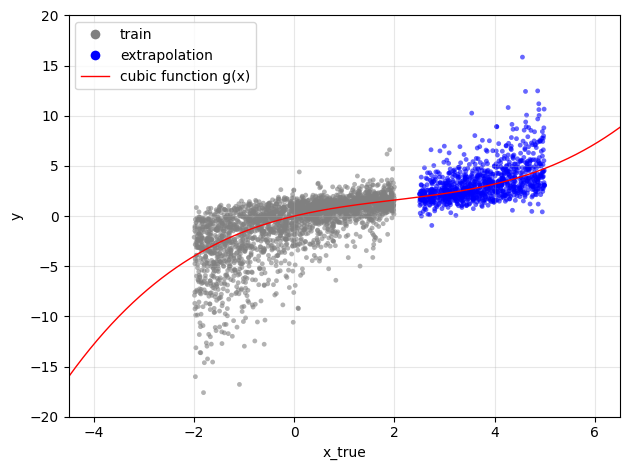

In [4]:
import matplotlib.pyplot as plt

# Define colors for each split
colors = {'train': 'gray', 'extrapolation': 'blue'}
split_colors = [colors[split] for split in data['split']]

# Create legend handles
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=8, label=split) 
          for split, color in colors.items()]

# Plot the data points: x_true vs y (showing the true underlying relationship)
plt.scatter(data['x_true'], data['y'], c=split_colors, s=12, alpha=0.6, edgecolor='none')

# Add the cubic function line
x_line = np.linspace(-4.5, 6.5, 1000)
y_line = cubic_function(x_line)
plt.plot(x_line, y_line, 'red', linewidth=1, label='cubic function g(x)')

# Add the function line to legend
handles.append(plt.Line2D([0], [0], color='red', linewidth=1, label='cubic function g(x)'))

plt.xlabel('x_true')
plt.ylabel('y')
plt.xlim(-4.5, 6.5)
plt.ylim(-20, 20)
plt.legend(handles=handles, loc='upper left')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()